# Mortgage Probability of Default (PD) Model

## 1. Business & Model Objective

Estimate the probability that an eligible mortgage, observed after 12 months of performance history and not already seriously delinquent, reaches **90+ days past due within the following 12 months**. The model supports proactive portfolio monitoring and prioritization of higher-risk mortgages.


## 2. Setup and Data Loading


In [1]:
# Check MORTGAGE PD MODEL — DEVELOPMENT ENVIRONMENT

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project paths

# Notebook is located under: banking_services_ai_assistant/notebooks/
PROJECT_ROOT = Path.cwd().parent

# Prepared Mortgage PD analytical dataset generated by
# 02_freddie_mac_data_preparation.ipynb.
PD_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "freddie_mac"
    / "2018"
    / "mortgage_pd_analytical.csv"
)

print("Dataset exists:", PD_DATA_PATH.exists())

Dataset exists: True


In [2]:
# LOAD MORTGAGE PD ANALYTICAL DATASET
# Each row represents an eligible mortgage observed after 12 months of performance history.

# Target: default_12m = whether the mortgage reaches 90+ DPD during the subsequent 12-month period.

df = pd.read_csv(
    PD_DATA_PATH,
    low_memory=False
)

print(f"Dataset shape: {df.shape}")

display(df.head())

Dataset shape: (44098, 43)


,credit_score,first_payment_date,first_time_homebuyer_flag,maturity_date,msa,mi_percentage,number_of_units,occupancy_status,original_cltv,original_dti,...,current_actual_upb,current_loan_delinquency_status,loan_age,remaining_months_to_maturity,current_interest_rate,current_deferred_upb,estimated_ltv,interest_bearing_upb,observation_date,default_12m
0,693,201803,N,203302,24340.0,0,1,P,80,41,...,124919.91,0.0,12,168,3.250,0.0,69,124919.91,2019-02-01,0
1,757,201803,Y,204802,NaN,25,1,P,97,10,...,26751.75,0.0,12,348,4.000,0.0,49,26751.75,2019-02-01,0
2,807,201803,N,203302,NaN,0,1,P,26,38,...,45632.04,0.0,12,168,3.250,0.0,22,45632.04,2019-02-01,0
3,812,201803,N,203302,19340.0,0,1,P,14,14,...,31653.56,0.0,12,168,3.750,0.0,12,31653.56,2019-02-01,0
4,661,201803,N,204802,41660.0,0,1,P,61,45,...,444946.15,0.0,12,348,3.875,0.0,62,444946.15,2019-02-01,0


## 3. Exploratory Risk Analysis


In [3]:
# Inspect the Dataset Structure

# Purpose: Understand the dimensions, data types, and overall structure of the prepared Mortgage PD analytical dataset.

print(f"Number of mortgages: {df.shape[0]:,}")
print(f"Number of variables: {df.shape[1]}")

print("\nData types:")
display(
    df.dtypes
      .value_counts()
      .rename("number_of_variables")
      .to_frame()
)

Number of mortgages: 44,098
Number of variables: 43

Data types:


,number_of_variables
int64,19
str,16
float64,8


### Target Distribution


,mortgages,percentage
default_12m,,
0,42918,97.32
1,1180,2.68


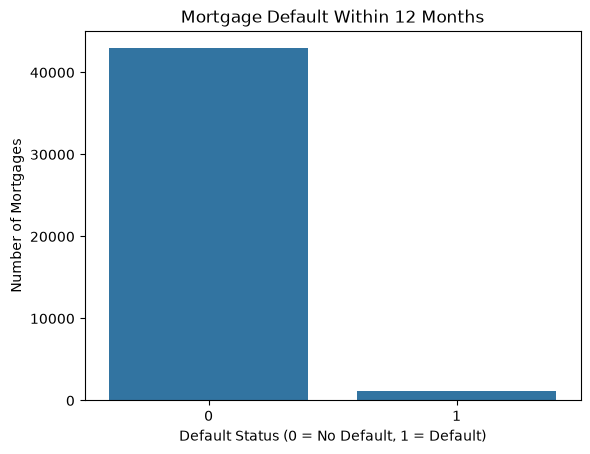

In [4]:
# TARGET DISTRIBUTION
# Business question:
# What proportion of eligible mortgages becomes seriously delinquent during the following 12 months?

target_summary = (
    df["default_12m"]
    .value_counts()
    .sort_index()
    .to_frame("mortgages")
)

target_summary["percentage"] = (
    target_summary["mortgages"] / len(df) * 100
).round(2)

display(target_summary)


# Visual representation of class imbalance.
sns.countplot(
    data=df,
    x="default_12m"
)

plt.title("Mortgage Default Within 12 Months")
plt.xlabel("Default Status (0 = No Default, 1 = Default)")
plt.ylabel("Number of Mortgages")
plt.show()

### Numerical Risk Characteristics


In [5]:
# CORE NUMERICAL RISK CHARACTERISTICS

core_numeric_features = [
    # Borrower creditworthiness / affordability
    "credit_score",
    "original_dti",

    # Original loan leverage
    "original_ltv",
    "original_cltv",
    "original_upb",

    # Loan pricing
    "original_interest_rate",

    # Current exposure at month 12
    "current_actual_upb",
    "current_interest_rate",
    "current_deferred_upb",

    # Current collateral leverage
    "estimated_ltv"
]

display(
    df[core_numeric_features]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
credit_score,44098.0,748.081682,159.383288,427.00,713.0000,752.000,784.000,9999.00
original_dti,44098.0,46.473808,101.508684,1.00,29.0000,37.000,44.000,999.00
original_ltv,44098.0,75.970520,17.893272,7.00,69.0000,80.000,90.000,999.00
original_cltv,44098.0,76.242460,17.886519,7.00,69.0000,80.000,90.000,999.00
original_upb,44098.0,225193.206041,118528.764852,19000.00,136000.0000,200000.000,295000.000,1041000.00
original_interest_rate,44098.0,4.716084,0.476699,2.50,4.3750,4.750,5.000,6.75
current_actual_upb,44098.0,217638.327043,116472.854509,46.94,130280.6575,193932.805,285319.725,1026230.88
current_interest_rate,44098.0,4.716081,0.476703,2.50,4.3750,4.750,5.000,6.75
current_deferred_upb,44098.0,0.055625,7.211873,0.00,0.0000,0.000,0.000,1092.37
estimated_ltv,44098.0,150.961563,262.967323,1.00,63.0000,74.000,86.000,999.00


### Numerical Risk Profile by Outcome


In [6]:
# 3.4 RISK CHARACTERISTICS BY DEFAULT OUTCOME

# Business question:
# Do mortgages that subsequently default exhibit different borrower, leverage, pricing, or exposure characteristics?

default_numeric_profile = (
    df.groupby("default_12m")[core_numeric_features]
      .mean()
      .T
)

default_numeric_profile.columns = [
    "No_Default",
    "Default"
]

# Calculate the relative difference between the two groups.
default_numeric_profile["Difference_%"] = (
    (
        default_numeric_profile["Default"]
        - default_numeric_profile["No_Default"]
    )
    / default_numeric_profile["No_Default"]
    * 100
).round(2)

display(default_numeric_profile.round(2))

,No_Default,Default,Difference_%
credit_score,749.01,714.35,-4.63
original_dti,46.34,51.50,11.14
original_ltv,75.85,80.36,5.94
original_cltv,76.12,80.68,5.98
original_upb,224683.77,243722.03,8.47
original_interest_rate,4.71,5.04,6.97
current_actual_upb,217047.29,239135.18,10.18
current_interest_rate,4.71,5.04,6.97
current_deferred_upb,0.05,0.33,576.47
estimated_ltv,150.74,158.98,5.47


##### **Numerical Risk Profile Conclusion**

Mortgages that default within the subsequent 12 months exhibit a distinct risk profile at both origination and the observation point. Future defaulters generally have lower credit scores, higher debt-to-income ratios, higher LTV/CLTV ratios, higher interest rates, and larger outstanding balances. These patterns are economically consistent with increased mortgage credit risk and support the predictive relevance of borrower creditworthiness, repayment capacity, leverage, pricing, and current exposure characteristics. The analysis also identified special coded values such as 999 and 9999 that must be treated as unavailable values during data cleaning before modeling.

### Categorical Risk Analysis


In [7]:
# 3.5 CATEGORICAL RISK ANALYSIS

# Business objective:
# Compare the future 12-month default rate across important borrower, loan, and property characteristics.

categorical_risk_features = [
    "first_time_homebuyer_flag",
    "occupancy_status",
    "channel",
    "property_type",
    "loan_purpose",
    "property_valuation_method"
]

# Calculate the number of mortgages and observed default rate for each category of each selected feature.

for feature in categorical_risk_features:

    risk_summary = (
        df.groupby(feature, dropna=False)
          .agg(
              mortgages=("default_12m", "size"),
              defaults=("default_12m", "sum"),
              default_rate=("default_12m", "mean")
          )
          .reset_index()
    )

    # Convert default rate to percentage for easier business interpretation.
    risk_summary["default_rate"] = (
        risk_summary["default_rate"] * 100
    ).round(2)

    # Show highest-risk categories first.
    risk_summary = risk_summary.sort_values(
        "default_rate",
        ascending=False
    )

    print(f"\n{feature.upper()}")
    display(risk_summary)


FIRST_TIME_HOMEBUYER_FLAG


,first_time_homebuyer_flag,mortgages,defaults,default_rate
1,Y,12095,427,3.53
0,N,32003,753,2.35



OCCUPANCY_STATUS


,occupancy_status,mortgages,defaults,default_rate
1,P,38389,1044,2.72
0,I,3784,99,2.62
2,S,1925,37,1.92



CHANNEL


...

,property_type,mortgages,defaults,default_rate
2,MH,188,6,3.19
0,CO,3563,111,3.12
3,PU,12296,325,2.64
4,SF,27971,737,2.63
1,CP,80,1,1.25



LOAN_PURPOSE


,loan_purpose,mortgages,defaults,default_rate
0,C,9123,264,2.89
2,P,29416,785,2.67
1,N,5559,131,2.36



PROPERTY_VALUATION_METHOD


,property_valuation_method,mortgages,defaults,default_rate
0,N,44098,1180,2.68


##### **Categorical Risk Profile Conclusion**

Future mortgage default rates vary across several borrower, origination, and property characteristics. First-time homebuyers exhibit a notably higher default rate (3.53%) than non-first-time buyers (2.35%), while origination channel also shows meaningful differences in subsequent default behavior. Property type, occupancy status, and loan purpose display more moderate variation, with some categories requiring cautious interpretation because of small populations. Property valuation method contains no variation and therefore provides no discriminatory information for the PD model. Overall, the categorical analysis supports retaining several borrower and loan characteristics for further modeling while identifying constant and low-information variables for potential exclusion during feature selection.

### Constant and Low-Information Variables


In [8]:
# CONSTANT / LOW-INFORMATION VARIABLES

# Variables containing only one observed value cannot
# discriminate between default and non-default mortgages.

unique_summary = pd.DataFrame({
    "unique_values": df.nunique(dropna=False)
}).sort_values("unique_values")

display(
    unique_summary[
        unique_summary["unique_values"] <= 2
    ]
)

,unique_values
amortization_type,1
ppm_flag,1
property_valuation_method,1
mi_cancellation_indicator,1
interest_only_indicator,1
loan_age,1
first_time_homebuyer_flag,2
servicer_name,2
program_indicator,2
harp_indicator,2


### Apply Cleaning Rules


In [9]:
# Purpose:
# Convert unavailable special codes to missing values and remove variables that provide no usable information for PD modeling.

# 1. Convert Freddie Mac unavailable-value codes to NaN

special_code_map = {
    "credit_score": [9999],
    "original_dti": [999],
    "original_ltv": [999],
    "original_cltv": [999],
    "estimated_ltv": [999]
}

for column, codes in special_code_map.items():
    df[column] = df[column].replace(codes, np.nan)

# 2. Drop extremely sparse variables

high_missing_features = [
    "mi_cancellation_indicator",
    "super_conforming_flag",
    "pre_harp_loan_sequence_number"
]

# 3. Drop constant variables

constant_features = [
    "amortization_type",
    "ppm_flag",
    "property_valuation_method",
    "interest_only_indicator",
    "loan_age"
]


# Combine removal list without duplicates
features_to_drop = list(
    set(high_missing_features + constant_features)
)

df = df.drop(
    columns=features_to_drop,
    errors="ignore"
)


print(f"Cleaned dataset shape: {df.shape}")

print("\nRemaining missing values:")
display(
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2)
    })
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)

Cleaned dataset shape: (44098, 35)

Remaining missing values:


,missing_count,missing_pct
msa,4730,10.73
estimated_ltv,3854,8.74
original_dti,491,1.11
credit_score,12,0.03
original_cltv,1,0.00
original_ltv,1,0.00


## 5. Feature Selection and Engineering


The initial feature set follows core mortgage credit-risk dimensions: borrower creditworthiness, repayment capacity, leverage/collateral, current exposure, pricing, payment behaviour, and origination characteristics.


**Theory-driven initial selection**
| Dimension             | Feature                           | Mortgage-risk rationale                                                                                                 |
| --------------------- | --------------------------------- | ----------------------------------------------------------------------------------------------------------------------- |
| Creditworthiness      | `credit_score`                    | Historical borrower credit quality; generally, lower scores imply higher PD.                                            |
| Repayment capacity    | `original_dti`                    | Measures debt burden relative to income; higher DTI can reduce ability to absorb financial stress.                      |
| Collateral / leverage | `original_ltv`                    | Higher original leverage means less borrower equity/cushion.                                                            |
| Current leverage      | `estimated_ltv`                   | Captures how leveraged the mortgage appears at the observation date.                                                    |
| Exposure              | `current_actual_upb`              | Current outstanding principal and scale of the mortgage obligation.                                                     |
| Pricing / risk        | `current_interest_rate`           | Higher borrowing cost can increase payment burden and may also reflect underlying loan characteristics.                 |
| Payment behaviour     | `current_loan_delinquency_status` | Arguably our strongest behavioural variable: being 30/60 DPD at month 12 is highly relevant to subsequent 90+ DPD risk. |
| Borrower profile      | `first_time_homebuyer_flag`       | Our EDA found materially different default rates: 4.51% vs 2.82% before the corrected population.                       |
| Origination           | `channel`                         | EDA showed meaningful risk differentiation across origination channels.                                                 |
| Loan purpose          | `loan_purpose`                    | Provides context about the economic purpose of the mortgage.                                                            |


In [10]:
# The initial PD model uses a parsimonious set of predictors
# representing the major dimensions of mortgage credit risk:
# - borrower creditworthiness
# - repayment capacity
# - leverage / collateral
# - current exposure
# - loan pricing
# - observed payment behaviour
# - borrower / origination characteristics

numeric_features = [
    "credit_score",
    "original_dti",
    "original_ltv",
    "estimated_ltv",
    "current_actual_upb",
    "current_interest_rate",
    "current_loan_delinquency_status"
]

categorical_features = [
    "first_time_homebuyer_flag",
    "channel",
    "loan_purpose"
]

target = "default_12m"

selected_features = numeric_features + categorical_features

X = df[selected_features].copy()
y = df[target].copy()

print(f"Selected predictors: {len(selected_features)}")
print(f"Modeling observations: {len(X):,}")

display(
    pd.DataFrame({
        "Feature": selected_features,
        "Type": (
            ["Numeric"] * len(numeric_features)
            + ["Categorical"] * len(categorical_features)
        )
    })
)

Selected predictors: 10
Modeling observations: 44,098


,Feature,Type
0,credit_score,Numeric
1,original_dti,Numeric
2,original_ltv,Numeric
3,estimated_ltv,Numeric
4,current_actual_upb,Numeric
5,current_interest_rate,Numeric
6,current_loan_delinquency_status,Numeric
7,first_time_homebuyer_flag,Categorical
8,channel,Categorical
9,loan_purpose,Categorical


### Numerical Redundancy Check


,credit_score,original_dti,original_ltv,estimated_ltv,current_actual_upb,current_interest_rate,current_loan_delinquency_status
credit_score,1.00,-0.13,-0.06,-0.08,0.04,-0.25,-0.09
original_dti,-0.13,1.00,0.09,0.10,0.14,0.10,0.03
original_ltv,-0.06,0.09,1.00,0.90,0.16,0.14,0.01
estimated_ltv,-0.08,0.10,0.90,1.00,0.26,0.16,0.02
current_actual_upb,0.04,0.14,0.16,0.26,1.00,-0.12,-0.00
current_interest_rate,-0.25,0.10,0.14,0.16,-0.12,1.00,0.05
current_loan_delinquency_status,-0.09,0.03,0.01,0.02,-0.00,0.05,1.00


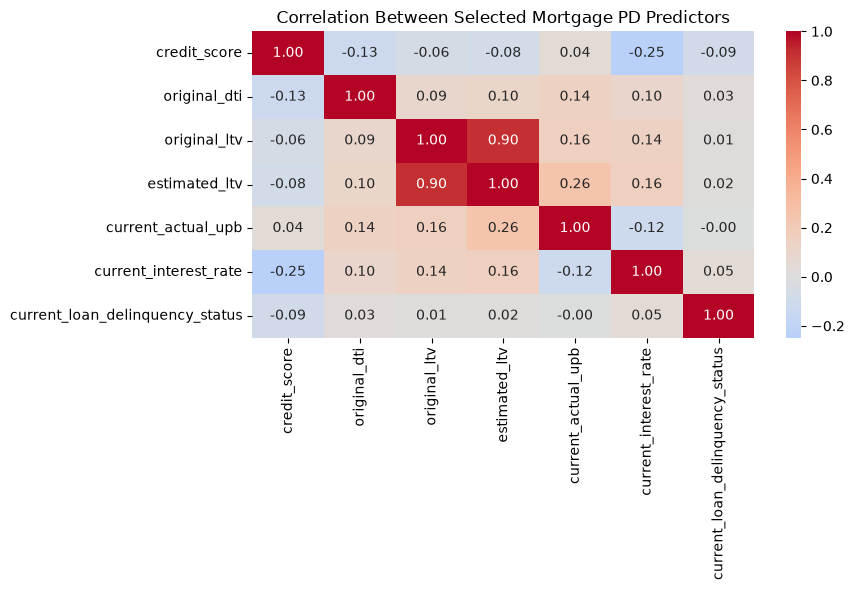

In [11]:
# Purpose:
# Assess relationships between the selected numerical predictors and identify potential redundancy before feature engineering.

# Strongly correlated predictors may provide overlapping information and reduce model interpretability.

# Calculate Pearson correlations between numerical predictors.
correlation_matrix = X[numeric_features].corr()

display(correlation_matrix.round(2))


# Visualize the correlation structure.
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Selected Mortgage PD Predictors")
plt.tight_layout()
plt.show()

`original_ltv` and `estimated_ltv` are strongly correlated. `estimated_ltv` is retained because it is closer to the month-12 observation point and therefore better reflects current leverage.


### Theory-Driven Feature Engineering


In [12]:
# Purpose:
# Create a small number of features with direct mortgage-risk interpretation rather than expanding the model unnecessarily.

# 1. Balance Paydown Ratio
# Measures the proportion of the original mortgage balance still outstanding at the month-12 observation point.

# Higher values = less principal has been repaid.

df["balance_paydown_ratio"] = (
    df["current_actual_upb"] / df["original_upb"]
)


# Inspect the engineered features.
engineered_features = [
    "balance_paydown_ratio"
]

display(
    df[engineered_features]
    .describe()
    .T
    .round(3)
)

,count,mean,std,min,25%,50%,75%,max
balance_paydown_ratio,44098.0,0.966,0.073,0.0,0.975,0.983,0.985,1.003


### Final Feature Set


In [13]:
numeric_features = [
    "credit_score",
    "original_dti",
    "estimated_ltv",
    "current_actual_upb",
    "current_interest_rate",
    "current_loan_delinquency_status",
    "balance_paydown_ratio"
]

categorical_features = [
    "first_time_homebuyer_flag",
    "channel",
    "loan_purpose"
]

selected_features = numeric_features + categorical_features

target = "default_12m"

X = df[selected_features].copy()
y = df[target].copy()

print(f"Final predictors: {len(selected_features)}")
print(f"Numerical predictors: {len(numeric_features)}")
print(f"Categorical predictors: {len(categorical_features)}")

Final predictors: 10
Numerical predictors: 7
Categorical predictors: 3


**Feature Engineering Conclusion**

Feature engineering was intentionally limited to financially interpretable transformations. The balance paydown ratio was retained as a measure of mortgage repayment progress, while interest rate change was excluded because it exhibited negligible variation. The final candidate set contains 10 predictors representing borrower creditworthiness, repayment capacity, current leverage, exposure, pricing, payment behaviour, amortization progress, and key borrower/origination characteristics.

## 6. Train/Test Split


In [14]:
# Purpose:
# Separate model development data from an untouched test set used only for final model evaluation.

# Stratification preserves the default / non-default distribution in both datasets.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training observations: {len(X_train):,}")
print(f"Test observations:     {len(X_test):,}")

print(
    f"\nTraining default rate: "
    f"{y_train.mean() * 100:.2f}%"
)

print(
    f"Test default rate: "
    f"{y_test.mean() * 100:.2f}%"
)

print(
    f"\nTraining defaults: {y_train.sum():,}"
)

print(
    f"Test defaults: {y_test.sum():,}"
)

Training observations: 35,278
Test observations:     8,820

Training default rate: 2.68%
Test default rate: 2.68%

Training defaults: 944
Test defaults: 236


## 7. Preprocessing Pipeline


Numerical features use median imputation and standardization. Categorical features use most-frequent imputation and one-hot encoding. All preprocessing is fitted inside the model pipeline using training data only.


In [15]:
# Purpose:
# Prepare numerical and categorical predictors for modeling while ensuring preprocessing parameters are learned only
# from the training data.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numerical preprocessing

# Median imputation handles missing numerical values.
# StandardScaler puts numerical predictors on comparable scales.

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
# Missing categories are replaced by the most frequent value.
# OneHotEncoder converts categories into model-ready indicators.

# handle_unknown="ignore" allows the model to process categories that were not present in the training data.

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ))
    ]
)

# Combine preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 8. Baseline Logistic Regression


In [16]:
# Purpose:
# Establish an interpretable benchmark using standard Logistic
# Regression before applying class weighting, tuning, or decision-threshold optimization.

# The complete pipeline ensures that preprocessing is fitted only on the training data.

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Build baseline end-to-end pipeline
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train model

baseline_model.fit(X_train, y_train)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


### Generate Baseline Predictions


In [17]:
# Binary prediction using the default 0.50 threshold.
y_pred_baseline = baseline_model.predict(X_test)

# Predicted probability of default (PD).
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline predictions generated.")
print(
    f"Predicted defaults: "
    f"{y_pred_baseline.sum():,} / {len(y_pred_baseline):,}"
)

print(
    f"Average predicted PD: "
    f"{y_prob_baseline.mean() * 100:.2f}%"
)

Baseline predictions generated.
Predicted defaults: 20 / 8,820
Average predicted PD: 2.66%


### Baseline Evaluation


In [18]:
# Purpose:
# Evaluate both:
# 1. Binary classification performance at threshold = 0.50
# 2. Probability-ranking/discrimination performance

# Accuracy alone is not sufficient because defaults represent only about 2.7% of the portfolio.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Classification metrics

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_baseline),
    "Precision": precision_score(
        y_test, y_pred_baseline, zero_division=0
    ),
    "Recall": recall_score(
        y_test, y_pred_baseline, zero_division=0
    ),
    "F1 Score": f1_score(
        y_test, y_pred_baseline, zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test, y_prob_baseline
    ),
    "PR-AUC": average_precision_score(
        y_test, y_prob_baseline
    )
}

baseline_metrics_df = (
    pd.DataFrame(
        baseline_metrics.items(),
        columns=["Metric", "Score"]
    )
)

display(
    baseline_metrics_df.round(3)
)


# Confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred_baseline
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual No Default", "Actual Default"],
    columns=["Predicted No Default", "Predicted Default"]
)

display(cm_df)


# Detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_baseline,
        digits=3,
        zero_division=0
    )
)

,Metric,Score
0,Accuracy,0.974
1,Precision,0.600
2,Recall,0.051
3,F1 Score,0.094
4,ROC-AUC,0.806
5,PR-AUC,0.172


,Predicted No Default,Predicted Default
Actual No Default,8576,8
Actual Default,224,12



Classification Report:
              precision    recall  f1-score   support

           0      0.975     0.999     0.987      8584
           1      0.600     0.051     0.094       236

    accuracy                          0.974      8820
   macro avg      0.787     0.525     0.540      8820
weighted avg      0.965     0.974     0.963      8820



**Baseline Model Conclusion** 

The baseline Logistic Regression demonstrates good discriminatory ability, with a ROC-AUC of 0.806 and PR-AUC of 0.172. However, at the standard 0.50 classification threshold, recall is only 5.1%, resulting in 224 of 236 defaults being missed. The high accuracy of 97.4% is largely driven by class imbalance and should not be used as the primary measure of performance. These results indicate that the model contains useful risk-ranking information, but class-imbalance treatment and decision-threshold optimization are required to improve default detection.

## 9. Class-Imbalance Challenger


In [19]:
# Purpose:
#Using standard Logistic Regression for applying class weighting to compare with the baseline model.

# The complete pipeline ensures that preprocessing is fitted only on the training data.

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Build baseline end-to-end pipeline
balanced_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
             class_weight="balanced",
            random_state=42
        ))
    ]
)

# Train model
balanced_model.fit(X_train, y_train)

print("Balanced Logistic Regression trained successfully.")

Balanced Logistic Regression trained successfully.


In [20]:
# Binary prediction using the default 0.50 threshold.
y_pred_balanced = balanced_model.predict(X_test)

# Predicted probability of default (PD).
y_prob_balanced = balanced_model.predict_proba(X_test)[:, 1]

print("Balanced predictions generated.")
print(
    f"Predicted defaults: "
    f"{y_pred_balanced.sum():,} / {len(y_pred_balanced):,}"
)

print(
    f"Average predicted PD: "
    f"{y_prob_balanced.mean() * 100:.2f}%"
)

Balanced predictions generated.
Predicted defaults: 2,622 / 8,820
Average predicted PD: 38.84%


In [21]:
# Purpose:
# Evaluate both:
# 1. Binary classification performance at threshold = 0.50
# 2. Probability-ranking/discrimination performance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Classification metrics

balanced_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_balanced),
    "Precision": precision_score(
        y_test, y_pred_balanced, zero_division=0
    ),
    "Recall": recall_score(
        y_test, y_pred_balanced, zero_division=0
    ),
    "F1 Score": f1_score(
        y_test, y_pred_balanced, zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test, y_prob_balanced
    ),
    "PR-AUC": average_precision_score(
        y_test, y_prob_balanced
    )
}

balanced_metrics_df = (
    pd.DataFrame(
        balanced_metrics.items(),
        columns=["Metric", "Score"]
    )
)

display(
    balanced_metrics_df.round(3)
)


# Confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred_balanced
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual No Default", "Actual Default"],
    columns=["Predicted No Default", "Predicted Default"]
)

display(cm_df)


# Detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_balanced,
        digits=3,
        zero_division=0
    )
)

,Metric,Score
0,Accuracy,0.715
1,Precision,0.066
2,Recall,0.737
3,F1 Score,0.122
4,ROC-AUC,0.805
5,PR-AUC,0.172


,Predicted No Default,Predicted Default
Actual No Default,6136,2448
Actual Default,62,174



Classification Report:
              precision    recall  f1-score   support

           0      0.990     0.715     0.830      8584
           1      0.066     0.737     0.122       236

    accuracy                          0.715      8820
   macro avg      0.528     0.726     0.476      8820
weighted avg      0.965     0.715     0.811      8820



**Class-Imbalance Experiment Conclusion**

Balanced class weighting substantially increased default recall from 5.1% to 73.7%, but precision declined from 60.0% to 6.6%, producing 2,448 false-positive alerts. Discriminatory performance remained essentially unchanged, with ROC-AUC around 0.805 and PR-AUC at 0.172 for both specifications. Furthermore, the balanced model produced an average predicted probability of 38.84%, far above the observed portfolio default rate of approximately 2.68%, limiting the direct interpretation of these probabilities as PD estimates. The standard Logistic Regression is therefore retained as the primary PD specification, while classification performance will be addressed separately through decision-threshold selection.

## 10. Probability Calibration and Threshold Selection


In [22]:
# 11. PROBABILITY CALIBRATION CHECK

# Purpose:
# Assess whether predicted probabilities correspond reasonably well to observed default rates across different risk levels.

# Mortgages are divided into 10 equally sized groups based ontheir predicted probability of default.
calibration_df = pd.DataFrame({
    "actual_default": y_test.values,
    "predicted_pd": y_prob_baseline
})

# Create PD risk deciles:
# 1 = lowest predicted risk
# 10 = highest predicted risk
calibration_df["risk_decile"] = pd.qcut(
    calibration_df["predicted_pd"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1


# Compare average predicted PD with actual default rate.
calibration_summary = (
    calibration_df
    .groupby("risk_decile")
    .agg(
        mortgages=("actual_default", "size"),
        predicted_pd=("predicted_pd", "mean"),
        observed_default_rate=("actual_default", "mean")
    )
    .reset_index()
)

# Convert probabilities to percentages for interpretation.
calibration_summary["predicted_pd_pct"] = (
    calibration_summary["predicted_pd"] * 100
).round(2)

calibration_summary["observed_default_pct"] = (
    calibration_summary["observed_default_rate"] * 100
).round(2)

display(
    calibration_summary[
        [
            "risk_decile",
            "mortgages",
            "predicted_pd_pct",
            "observed_default_pct"
        ]
    ]
)

,risk_decile,mortgages,predicted_pd_pct,observed_default_pct
0,1,882,0.29,0.23
1,2,882,0.61,0.34
2,3,882,0.89,0.68
3,4,882,1.18,0.45
4,5,882,1.49,0.79
5,6,882,1.85,1.93
6,7,882,2.34,2.83
7,8,882,3.07,3.17
8,9,882,4.24,4.08
9,10,882,10.60,12.24


**Calibration Conclusion**

The baseline Logistic Regression demonstrates reasonable probability calibration and strong risk differentiation. Observed default rates generally increase with predicted PD, from 0.23% in the lowest-risk decile to 12.24% in the highest-risk decile. Predicted and observed default rates are particularly well aligned across the middle and upper risk groups, although some overestimation occurs in lower-risk groups and modest underestimation occurs in the highest-risk group. Given the overall alignment and limited number of defaults in the test sample, no additional probability-calibration method is applied.

### Decision Threshold Analysis


In [23]:
# 12.1 DECISION THRESHOLD ANALYSIS

# Purpose:
# Evaluate how different PD thresholds affect the trade-off between default detection (recall) and false-positive alerts.

# The underlying PD model is unchanged. Only the decision rule used to flag high-risk mortgages is being evaluated.

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

candidate_thresholds = [
    0.02,
    0.03,
    0.04,
    0.05,
    0.075,
    0.10,
    0.15,
    0.20
]

threshold_results = []

for threshold in candidate_thresholds:

    # Convert predicted PD into a binary risk flag.
    y_pred_threshold = (
        y_prob_baseline >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "recall": recall_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "f1_score": f1_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "defaults_detected": tp,
        "defaults_missed": fn,
        "false_positives": fp,
        "mortgages_flagged": tp + fp,
        "flag_rate": (tp + fp) / len(y_test)
    })


threshold_results_df = pd.DataFrame(
    threshold_results
)

# Convert rates to percentages for easier interpretation.
threshold_results_df["threshold_pct"] = (
    threshold_results_df["threshold"] * 100
).round(1)

threshold_results_df["precision_pct"] = (
    threshold_results_df["precision"] * 100
).round(1)

threshold_results_df["recall_pct"] = (
    threshold_results_df["recall"] * 100
).round(1)

threshold_results_df["flag_rate_pct"] = (
    threshold_results_df["flag_rate"] * 100
).round(1)


display(
    threshold_results_df[
        [
            "threshold_pct",
            "precision_pct",
            "recall_pct",
            "f1_score",
            "defaults_detected",
            "defaults_missed",
            "false_positives",
            "mortgages_flagged",
            "flag_rate_pct"
        ]
    ].round(3)
)

,threshold_pct,precision_pct,recall_pct,f1_score,defaults_detected,defaults_missed,false_positives,mortgages_flagged,flag_rate_pct
0,2.0,5.5,85.2,0.103,201,35,3457,3658,41.5
1,3.0,7.0,66.9,0.127,158,78,2099,2257,25.6
2,4.0,9.1,54.7,0.156,129,107,1290,1419,16.1
3,5.0,11.7,47.0,0.187,111,125,841,952,10.8
4,7.5,17.3,31.4,0.223,74,162,353,427,4.8
5,10.0,21.6,20.3,0.210,48,188,174,222,2.5
6,15.0,29.3,12.3,0.173,29,207,70,99,1.1
7,20.0,44.4,10.2,0.166,24,212,30,54,0.6


**Threshold Selection Conclusion**

A 5% PD threshold was selected as the initial operating cutoff for the mortgage early-warning model. At this threshold, the model identifies 47.0% of observed defaults while flagging 10.8% of the mortgage portfolio for review. This provides a practical compromise between default detection and operational workload. Lower thresholds improve recall but generate substantially larger review populations, while higher thresholds improve precision at the cost of missing a significant proportion of defaults. The threshold should therefore be interpreted as a business decision rule applied to the estimated PD rather than an intrinsic property of the statistical model.

### Final Evaluation at the 5% Threshold


In [24]:
# 13.1 FINAL MODEL EVALUATION — SELECTED 5% PD THRESHOLD

# Purpose:
# Evaluate the selected Logistic Regression PD model using the 5% operating threshold chosen for proactive risk monitoring.

# The underlying predicted PDs remain unchanged.
FINAL_THRESHOLD = 0.05

# Apply selected operating threshold.
y_pred_final = (
    y_prob_baseline >= FINAL_THRESHOLD
).astype(int)

# Final performance metrics
final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(
        y_test, y_pred_final, zero_division=0
    ),
    "Recall": recall_score(
        y_test, y_pred_final, zero_division=0
    ),
    "F1 Score": f1_score(
        y_test, y_pred_final, zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test, y_prob_baseline
    ),
    "PR-AUC": average_precision_score(
        y_test, y_prob_baseline
    )
}

final_metrics_df = pd.DataFrame(
    final_metrics.items(),
    columns=["Metric", "Score"]
)

display(final_metrics_df.round(3))

# Confusion matrix
cm_final = confusion_matrix(
    y_test,
    y_pred_final
)

cm_final_df = pd.DataFrame(
    cm_final,
    index=["Actual No Default", "Actual Default"],
    columns=["Predicted No Default", "Predicted Default"]
)

display(cm_final_df)

# Operational summary
tn, fp, fn, tp = cm_final.ravel()

print(f"Selected PD threshold: {FINAL_THRESHOLD:.0%}")
print(f"Defaults detected:     {tp:,}")
print(f"Defaults missed:       {fn:,}")
print(f"False positives:       {fp:,}")
print(f"Mortgages flagged:     {tp + fp:,}")
print(
    f"Portfolio flag rate:   "
    f"{(tp + fp) / len(y_test) * 100:.1f}%"
)

,Metric,Score
0,Accuracy,0.890
1,Precision,0.117
2,Recall,0.470
3,F1 Score,0.187
4,ROC-AUC,0.806
5,PR-AUC,0.172


,Predicted No Default,Predicted Default
Actual No Default,7743,841
Actual Default,125,111


Selected PD threshold: 5%
Defaults detected:     111
Defaults missed:       125
False positives:       841
Mortgages flagged:     952
Portfolio flag rate:   10.8%


**Final Evaluation Conclusion**

At the selected 5% PD threshold, the Logistic Regression identifies 111 of 236 defaults, achieving 47.0% recall and 11.7% precision while flagging 10.8% of mortgages for review. The model maintains a ROC-AUC of 0.806 and PR-AUC of 0.172, indicating useful discrimination despite the highly imbalanced default outcome. The selected threshold substantially improves default detection compared with the standard 50% cutoff while maintaining a manageable monitoring population. These results support its use as an initial early-warning decision rule rather than as an automatic credit decision.

## 11. Model Interpretation


In [25]:
# 14.1 MODEL INTERPRETATION — LOGISTIC REGRESSION COEFFICIENTS

# Purpose:
# Extract the fitted Logistic Regression coefficients and identify which features are associated with higher or lower default risk.

# Positive coefficient  -> higher predicted default risk
# Negative coefficient  -> lower predicted default risk

# Retrieve fitted preprocessing and classification components.
fitted_preprocessor = baseline_model.named_steps["preprocessor"]
fitted_classifier = baseline_model.named_steps["classifier"]

# Get feature names after preprocessing / one-hot encoding.
feature_names = fitted_preprocessor.get_feature_names_out()

# Extract Logistic Regression coefficients.
coefficients = fitted_classifier.coef_[0]

# Create interpretation table.
coefficient_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Remove pipeline prefixes for readability.
coefficient_df["feature"] = (
    coefficient_df["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

# Add odds ratios.
coefficient_df["odds_ratio"] = np.exp(
    coefficient_df["coefficient"]
)

# Rank features by absolute coefficient magnitude.
coefficient_df["absolute_coefficient"] = (
    coefficient_df["coefficient"].abs()
)

coefficient_df = (
    coefficient_df
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    coefficient_df[
        ["feature", "coefficient", "odds_ratio"]
    ].round(3)
)

,feature,coefficient,odds_ratio
0,current_interest_rate,0.486,1.625
1,credit_score,-0.399,0.671
2,original_dti,0.324,1.382
3,first_time_homebuyer_flag_Y,0.307,1.360
4,current_loan_delinquency_status,0.244,1.276
5,current_actual_upb,0.210,1.233
6,balance_paydown_ratio,0.206,1.228
7,loan_purpose_N,0.200,1.222
8,estimated_ltv,0.162,1.175
9,channel_R,-0.154,0.858


**Model Interpretation Conclusion**

The Logistic Regression produces economically coherent relationships with mortgage default risk. Higher current interest rates, DTI, current delinquency, outstanding balances, limited principal paydown, and estimated LTV are associated with higher predicted PD, while stronger credit scores are associated with lower risk. First-time homebuyer status and selected loan-purpose and origination-channel categories also contribute to risk differentiation. Overall, the model provides an interpretable link between borrower creditworthiness, repayment capacity, leverage, loan performance, and 12-month default risk.

| Feature                        |  Coef. | Odds ratio | Interpretation                                                                                                                                                     |
| ------------------------------ | -----: | ---------: | ------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Current interest rate**      | +0.486 |      1.625 | Higher interest rates are associated with **higher default risk**. A 1-SD increase corresponds to ~62.5% higher odds of default, holding other variables constant. |
| **Credit score**               | −0.399 |      0.671 | Higher creditworthiness is strongly associated with **lower risk**. A 1-SD increase corresponds to ~32.9% lower default odds.                                      |
| **Original DTI**               | +0.324 |      1.382 | Higher debt burden relative to income is associated with **higher risk** (~38.2% higher odds per 1 SD).                                                            |
| **First-time homebuyer = Y**   | +0.307 |      1.360 | First-time buyers have ~36.0% higher default odds than **non-first-time buyers**, all else equal.                                                                  |
| **Current delinquency status** | +0.244 |      1.276 | Existing payment difficulty at the observation point is associated with **higher future default risk** (~27.6% higher odds per 1 SD).                              |
| **Current actual UPB**         | +0.210 |      1.233 | Larger outstanding mortgage balances are associated with **higher default risk** (~23.3% higher odds per 1 SD).                                                    |
| **Balance paydown ratio**      | +0.206 |      1.228 | A higher remaining-balance/original-balance ratio—i.e. **less principal paid down**—is associated with higher risk.                                                |
| **Loan purpose = N**           | +0.200 |      1.222 | `N` loans have ~22.2% higher default odds than the omitted **C reference category**, holding other factors constant.                                               |
| **Estimated LTV**              | +0.162 |      1.175 | Higher current leverage/equity pressure is associated with **higher risk** (~17.5% higher odds per 1 SD).                                                          |
| **Channel = R**                | −0.154 |      0.858 | `R` channel loans have ~14.2% lower default odds than the omitted **B reference channel**.                                                                         |
| **Loan purpose = P**           | −0.149 |      0.861 | `P` loans have ~13.9% lower default odds than the omitted **C reference category**.                                                                                |
| **Channel = C**                | +0.058 |      1.060 | `C` channel loans have ~6.0% higher default odds than the omitted **B reference channel**; this is a relatively weak effect.                                       |


## 12. Save and Validate Final Model


In [26]:
# PACKAGE MORTGAGE PD MODEL FOR DEPLOYMENT

# Purpose:
# Save the complete fitted pipeline, operating threshold, feature schema, and essential model metadata as one artifact.

from pathlib import Path
from datetime import datetime
import joblib

# Artifact location
ARTIFACT_DIR = Path("../models/artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

artifact_path = (
    ARTIFACT_DIR / "mortgage_pd_classifier_v1.joblib"
)

# Build deployment artifact

mortgage_pd_artifact = {

    # Complete fitted preprocessing + Logistic Regression pipeline
    "model_pipeline": baseline_model,

    # Business decision rule
    "threshold": FINAL_THRESHOLD,

    # Expected raw model inputs
    "features": selected_features,

    # Metadata for traceability
    "metadata": {
        "model_name": "Mortgage 12-Month PD Classifier",
        "model_version": "1.0",
        "model_type": "Logistic Regression",
        "target": target,
        "prediction_horizon": "12 months",
        "observation_point": "First chronological loan age 12",
        "training_dataset": "Freddie Mac Single-Family Loan-Level Dataset",
        "training_vintage": "2018",
        "created_at": datetime.now().isoformat(timespec="seconds"),

        # Final evaluation metrics
        "roc_auc": round(
            roc_auc_score(y_test, y_prob_baseline), 3
        ),
        "pr_auc": round(
            average_precision_score(y_test, y_prob_baseline), 3
        ),
        "precision_at_threshold": round(
            precision_score(y_test, y_pred_final), 3
        ),
        "recall_at_threshold": round(
            recall_score(y_test, y_pred_final), 3
        ),
        "f1_at_threshold": round(
            f1_score(y_test, y_pred_final), 3
        )
    }
}

# Save artifact

joblib.dump(
    mortgage_pd_artifact,
    artifact_path
)

print(f"Model artifact saved successfully to:")
print(artifact_path)

Model artifact saved successfully to:
..\models\artifacts\mortgage_pd_classifier_v1.joblib


### Reload and Validate Artifact


In [27]:
# 15.2 RELOAD AND VALIDATE DEPLOYMENT ARTIFACT

# Purpose:
# Verify that the serialized artifact can be reloaded and used independently to generate both PD and the final risk flag.

# Reload artifact from disk.
loaded_artifact = joblib.load(artifact_path)

loaded_model = loaded_artifact["model_pipeline"]
loaded_threshold = loaded_artifact["threshold"]
loaded_features = loaded_artifact["features"]

# Create one sample mortgage
sample_mortgage = X_test.iloc[[0]][loaded_features]

# Generate deployment-style prediction
predicted_pd = loaded_model.predict_proba(
    sample_mortgage
)[:, 1][0]

risk_flag = int(
    predicted_pd >= loaded_threshold
)

# Validate serialization consistency
original_pd = baseline_model.predict_proba(
    sample_mortgage
)[:, 1][0]

assert np.isclose(
    original_pd,
    predicted_pd
), "Reloaded model prediction does not match original model."


print("Artifact validation successful.")
print(f"Predicted 12-month PD: {predicted_pd:.2%}")
print(f"Operating threshold:   {loaded_threshold:.2%}")
print(
    f"Risk classification:   "
    f"{'HIGH RISK' if risk_flag == 1 else 'LOW RISK'}"
)

Artifact validation successful.
Predicted 12-month PD: 0.92%
Operating threshold:   5.00%
Risk classification:   LOW RISK


**Model Packaging Conclusion**

The final Mortgage PD model was successfully packaged as mortgage_pd_classifier_v1.joblib, including the fitted preprocessing and Logistic Regression pipeline, the 5% operating threshold, feature schema, and model metadata. The artifact was successfully reloaded and reproduced the original model prediction, confirming serialization consistency and readiness for downstream inference and API integration.

## Mortgage PD Model Development Process


1. Define the business objective and 12-month default target.
2. Load the prepared month-12 mortgage analytical dataset.
3. Review target imbalance and key borrower/mortgage risk characteristics.
4. Clean unavailable codes and remove sparse or constant variables.
5. Select theory-driven predictors and assess redundancy.
6. Engineer the balance paydown ratio and lock the final 10-feature set.
7. Create a stratified train/test split and preprocessing pipeline.
8. Train standard Logistic Regression as the PD baseline.
9. Compare a class-balanced challenger and retain the standard model for probability estimation.
10. Assess probability calibration and select a 5% monitoring threshold.
11. Evaluate and interpret the final model.
12. Save and reload `mortgage_pd_classifier_v1.joblib` for deployment validation.
